# NeuroScan AI — Unified Training Pipeline

Trains **any model in the registry** with a single config change.

Supported families:
- 🔬 **Custom** — MultiBranch (EfficientNet + Patches + ViT)
- 📦 **torchvision** — ResNet-18/34/50/101/152, EfficientNet-B0–B7, EfficientNet-V2-S/M/L, DenseNet-121/161/169/201
- 🏥 **MONAI** — EfficientNet-B0–B7, DenseNet-121/169/201/264

Pipeline:
1. Install & imports
2. **Config** — set `MODEL_NAME` and paths, everything adapts
3. Dataset & transforms (auto per model)
4. DataLoaders
5. Model build
6. Freeze strategy (auto per family)
7. Phase 1 — head warmup
8. Phase 2 — full fine-tune
9. Evaluation (AUC, confusion matrix, ROC)
10. Speed test
11. Save checkpoint

## 1. Install Dependencies

In [1]:
!pip install -q 'monai[all]' torchmetrics scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5

## 2. Imports

In [2]:
import os, sys, glob, random, time, json, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc as sk_auc
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

# ── MONAI (optional) ─────────────────────────────────────────────────────────
try:
    import monai
    from monai.networks.nets import (
        EfficientNetBN,
        DenseNet121 as MoniaDenseNet121,
        DenseNet169 as MoniaDenseNet169,
        DenseNet201 as MoniaDenseNet201,
        DenseNet264 as MoniaDenseNet264,
    )
    from monai.transforms import (
        Compose, LoadImaged, EnsureChannelFirstd, Lambdad,
        ScaleIntensityd, ResizeD,
        RandFlipd, RandRotated, RandZoomd,
        RandAdjustContrastd, RandGaussianNoised,
        ToTensord,
    )
    from monai.data import Dataset as MonaiDataset
    from monai.losses import FocalLoss
    from monai.metrics import ROCAUCMetric
    from monai.utils import set_determinism
    MONAI_AVAILABLE = True
    print(f'MONAI {monai.__version__} ✓')
except ImportError:
    MONAI_AVAILABLE = False
    print('MONAI not found — MONAI models will be unavailable')

print(f'PyTorch {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-11 15:59:03.355246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775923143.549410      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775923143.610202      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775923144.090272      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775923144.090317      22 computation_placer.cc:1

MONAI 1.5.2 ✓
PyTorch 2.10.0+cu128
GPU: Tesla T4


## 3. Configuration

**Only edit this cell.** Set `MODEL_NAME` to any key from the registry below.

```
# ── Custom ───────────────────────────────────────────────────────────────────
MultiBranch (EfficientNet + Patches + ViT)

# ── torchvision · ResNet ─────────────────────────────────────────────────────
ResNet-18  |  ResNet-34  |  ResNet-50  |  ResNet-101  |  ResNet-152

# ── torchvision · EfficientNet ───────────────────────────────────────────────
EfficientNet-B0 (torchvision)  ...  EfficientNet-B7 (torchvision)

# ── torchvision · EfficientNet-V2 ────────────────────────────────────────────
EfficientNet-V2-S (torchvision)  |  EfficientNet-V2-M  |  EfficientNet-V2-L

# ── torchvision · DenseNet ───────────────────────────────────────────────────
DenseNet-121 (torchvision)  |  DenseNet-161  |  DenseNet-169  |  DenseNet-201

# ── MONAI · EfficientNet ─────────────────────────────────────────────────────
MONAI EfficientNet-B0  ...  MONAI EfficientNet-B7

# ── MONAI · DenseNet ─────────────────────────────────────────────────────────
MONAI DenseNet-121  |  MONAI DenseNet-169  |  MONAI DenseNet-201  |  MONAI DenseNet-264
```

In [3]:
# ════════════════════════════════════════════════════════════════════════════
#  EDIT THIS CELL ONLY
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "DenseNet-161 (torchvision)"   # <── pick from the list above

# ── Paths ────────────────────────────────────────────────────────────────────
# Expects two sub-folders named after your classes, e.g.:
#   DATA_ROOT/
#     ET/   *.png
#     PD/   *.png
DATA_ROOT   = "/kaggle/input/datasets/oovamoyo/preprocessed-dataset-3/processed"
CLASS_DIRS  = ["ET", "PD"]           # folder names → label indices 0, 1, ...
OUTPUT_DIR  = "/kaggle/working/outputs"

# ── Data splits ──────────────────────────────────────────────────────────────
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE      = 32
NUM_WORKERS     = 4
PHASE1_LR       = 1e-3
PHASE1_EPOCHS   = 5
PHASE2_LR       = 1e-4
PHASE2_EPOCHS   = 20
FOCAL_GAMMA     = 2.0    # 0 = cross-entropy, >0 = focal loss (MONAI models)
EARLY_STOP_PAT  = 7      # stop Phase 2 if val AUC doesn't improve for N epochs

# ════════════════════════════════════════════════════════════════════════════
#  DO NOT EDIT BELOW THIS LINE
# ════════════════════════════════════════════════════════════════════════════
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if MONAI_AVAILABLE: set_determinism(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = CLASS_DIRS
NUM_CLASSES = len(CLASS_DIRS)
print(f'Model      : {MODEL_NAME}')
print(f'Classes    : {CLASS_NAMES}')
print(f'Device     : {DEVICE}')

Model      : DenseNet-161 (torchvision)
Classes    : ['ET', 'PD']
Device     : cuda


## 4. Model Registry

In [4]:
# ── Custom MultiBranch ────────────────────────────────────────────────────────
class MultiBranchModel(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.efficientnet = models.efficientnet_b0(pretrained=True)
        self.efficientnet.features[0][0] = nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False)
        self.efficientnet.classifier = nn.Identity()
        self.branch1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(1280, 512),
            nn.BatchNorm1d(512), nn.SiLU(inplace=True),
        )
        self.branch2_conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=4),
            nn.LayerNorm([64, 64, 64]),
        )
        self.branch2_proj = nn.Linear(64, 512)
        self.patch_embed  = nn.Conv2d(1, 768, kernel_size=16, stride=16)
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, 768))
        self.pos_embed    = nn.Parameter(torch.zeros(1, 257, 768))
        self.branch3_proj = nn.Linear(768, 512)
        self.classifier   = nn.Sequential(
            nn.Linear(512*3, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x1 = self.branch1(self.efficientnet.features(x))
        x2 = F.silu(self.branch2_proj(torch.flatten(F.adaptive_avg_pool2d(self.branch2_conv(x),(1,1)),1)))
        x3 = self.patch_embed(x).flatten(2).transpose(1,2)
        x3 = torch.cat((self.cls_token.expand(x3.shape[0],-1,-1), x3), dim=1) + self.pos_embed
        x3 = F.silu(self.branch3_proj(x3[:,0]))
        return self.classifier(torch.cat([x1,x2,x3], dim=1))


# ── Registry ──────────────────────────────────────────────────────────────────
def _tv_resnet(v):
    def build(nc):
        m = getattr(models, v)(pretrained=True)
        m.conv1 = nn.Conv2d(1, m.conv1.out_channels, m.conv1.kernel_size,
                             m.conv1.stride, m.conv1.padding, bias=False)
        m.fc = nn.Linear(m.fc.in_features, nc)
        return m
    return build

def _tv_effnet(v):
    def build(nc):
        m = getattr(models, v)(pretrained=True)
        old = m.features[0][0]
        m.features[0][0] = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
        m.classifier[1]  = nn.Linear(m.classifier[1].in_features, nc)
        return m
    return build

def _tv_effnet_v2(v):
    def build(nc):
        m = getattr(models, v)(pretrained=True)
        old = m.features[0][0]
        m.features[0][0] = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
        m.classifier[1]  = nn.Linear(m.classifier[1].in_features, nc)
        return m
    return build

def _tv_densenet(v):
    def build(nc):
        m = getattr(models, v)(pretrained=True)
        old = m.features.conv0
        m.features.conv0 = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding, bias=False)
        m.classifier = nn.Linear(m.classifier.in_features, nc)
        return m
    return build

def _monai_effnet(v):
    def build(nc):
        return EfficientNetBN(model_name=v, pretrained=True, spatial_dims=2, in_channels=1, num_classes=nc)
    return build

def _monai_densenet(cls_):
    def build(nc):
        return cls_(spatial_dims=2, in_channels=1, out_channels=nc)
    return build


MODEL_REGISTRY = {
    # Custom
    'MultiBranch (EfficientNet + Patches + ViT)':  {'family':'custom',      'build': lambda nc: MultiBranchModel(nc),          'img_size':256},
    # ResNet
    'ResNet-18':   {'family':'torchvision', 'build': _tv_resnet('resnet18'),  'img_size':224},
    'ResNet-34':   {'family':'torchvision', 'build': _tv_resnet('resnet34'),  'img_size':224},
    'ResNet-50':   {'family':'torchvision', 'build': _tv_resnet('resnet50'),  'img_size':224},
    'ResNet-101':  {'family':'torchvision', 'build': _tv_resnet('resnet101'), 'img_size':224},
    'ResNet-152':  {'family':'torchvision', 'build': _tv_resnet('resnet152'), 'img_size':224},
    # EfficientNet
    'EfficientNet-B0 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b0'), 'img_size':224},
    'EfficientNet-B1 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b1'), 'img_size':240},
    'EfficientNet-B2 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b2'), 'img_size':260},
    'EfficientNet-B3 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b3'), 'img_size':300},
    'EfficientNet-B4 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b4'), 'img_size':380},
    'EfficientNet-B5 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b5'), 'img_size':456},
    'EfficientNet-B6 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b6'), 'img_size':528},
    'EfficientNet-B7 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b7'), 'img_size':600},
    # EfficientNet-V2
    'EfficientNet-V2-S (torchvision)': {'family':'torchvision', 'build': _tv_effnet_v2('efficientnet_v2_s'), 'img_size':384},
    'EfficientNet-V2-M (torchvision)': {'family':'torchvision', 'build': _tv_effnet_v2('efficientnet_v2_m'), 'img_size':480},
    'EfficientNet-V2-L (torchvision)': {'family':'torchvision', 'build': _tv_effnet_v2('efficientnet_v2_l'), 'img_size':480},
    # DenseNet
    'DenseNet-121 (torchvision)': {'family':'torchvision', 'build': _tv_densenet('densenet121'), 'img_size':224},
    'DenseNet-161 (torchvision)': {'family':'torchvision', 'build': _tv_densenet('densenet161'), 'img_size':224},
    'DenseNet-169 (torchvision)': {'family':'torchvision', 'build': _tv_densenet('densenet169'), 'img_size':224},
    'DenseNet-201 (torchvision)': {'family':'torchvision', 'build': _tv_densenet('densenet201'), 'img_size':224},
    # MONAI EfficientNet
    'MONAI EfficientNet-B0': {'family':'monai', 'build': _monai_effnet('efficientnet-b0'), 'img_size':224},
    'MONAI EfficientNet-B1': {'family':'monai', 'build': _monai_effnet('efficientnet-b1'), 'img_size':240},
    'MONAI EfficientNet-B2': {'family':'monai', 'build': _monai_effnet('efficientnet-b2'), 'img_size':260},
    'MONAI EfficientNet-B3': {'family':'monai', 'build': _monai_effnet('efficientnet-b3'), 'img_size':300},
    'MONAI EfficientNet-B4': {'family':'monai', 'build': _monai_effnet('efficientnet-b4'), 'img_size':380},
    'MONAI EfficientNet-B5': {'family':'monai', 'build': _monai_effnet('efficientnet-b5'), 'img_size':456},
    'MONAI EfficientNet-B6': {'family':'monai', 'build': _monai_effnet('efficientnet-b6'), 'img_size':528},
    'MONAI EfficientNet-B7': {'family':'monai', 'build': _monai_effnet('efficientnet-b7'), 'img_size':600},
    # MONAI DenseNet
    'MONAI DenseNet-121': {'family':'monai', 'build': _monai_densenet(MoniaDenseNet121), 'img_size':224},
    'MONAI DenseNet-169': {'family':'monai', 'build': _monai_densenet(MoniaDenseNet169), 'img_size':224},
    'MONAI DenseNet-201': {'family':'monai', 'build': _monai_densenet(MoniaDenseNet201), 'img_size':224},
    'MONAI DenseNet-264': {'family':'monai', 'build': _monai_densenet(MoniaDenseNet264), 'img_size':224},
} if MONAI_AVAILABLE else {
    k: v for k, v in {
        'MultiBranch (EfficientNet + Patches + ViT)': {'family':'custom',      'build': lambda nc: MultiBranchModel(nc), 'img_size':256},
        'ResNet-18':  {'family':'torchvision', 'build': _tv_resnet('resnet18'),  'img_size':224},
        'ResNet-34':  {'family':'torchvision', 'build': _tv_resnet('resnet34'),  'img_size':224},
        'ResNet-50':  {'family':'torchvision', 'build': _tv_resnet('resnet50'),  'img_size':224},
        'ResNet-101': {'family':'torchvision', 'build': _tv_resnet('resnet101'), 'img_size':224},
        'ResNet-152': {'family':'torchvision', 'build': _tv_resnet('resnet152'), 'img_size':224},
        'EfficientNet-B0 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b0'), 'img_size':224},
        'EfficientNet-B4 (torchvision)': {'family':'torchvision', 'build': _tv_effnet('efficientnet_b4'), 'img_size':380},
        'EfficientNet-V2-S (torchvision)': {'family':'torchvision', 'build': _tv_effnet_v2('efficientnet_v2_s'), 'img_size':384},
        'DenseNet-121 (torchvision)': {'family':'torchvision', 'build': _tv_densenet('densenet121'), 'img_size':224},
    }.items()
}

assert MODEL_NAME in MODEL_REGISTRY, f"'{MODEL_NAME}' not in registry. Check spelling."
cfg      = MODEL_REGISTRY[MODEL_NAME]
FAMILY   = cfg['family']
IMG_SIZE = cfg['img_size']
print(f'Family     : {FAMILY}')
print(f'Image size : {IMG_SIZE}×{IMG_SIZE}')

Family     : torchvision
Image size : 224×224


## 5. Dataset

In [5]:
def build_data_list(data_root, class_dirs):
    data = []
    for label, cls in enumerate(class_dirs):
        folder = os.path.join(data_root, cls)
        files  = sorted(
            glob.glob(os.path.join(folder, '**/*.png'), recursive=True) +
            glob.glob(os.path.join(folder, '*.png'))
        )
        data += [{'image': f, 'label': label} for f in files]
        print(f'  {cls:>10} : {len(files):>6} slices')
    random.shuffle(data)
    return data

print('Loading file list…')
all_data = build_data_list(DATA_ROOT, CLASS_DIRS)
labels   = [d['label'] for d in all_data]

train_val, test_data = train_test_split(all_data, test_size=TEST_SPLIT, stratify=labels, random_state=SEED)
tv_labels = [d['label'] for d in train_val]
train_data, val_data = train_test_split(train_val, test_size=VAL_SPLIT/(1-TEST_SPLIT), stratify=tv_labels, random_state=SEED)

print(f'\nTotal : {len(all_data):>6}')
print(f'Train : {len(train_data):>6}')
print(f'Val   : {len(val_data):>6}')
print(f'Test  : {len(test_data):>6}')

Loading file list…
          ET :   2384 slices
          PD :   5660 slices

Total :   8044
Train :   5630
Val   :   1207
Test  :   1207


## 6. Transforms & DataLoaders

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  MONAI dict-based transforms
# ─────────────────────────────────────────────────────────────────────────────
if FAMILY == 'monai' and MONAI_AVAILABLE:
    _train_tf = Compose([
        LoadImaged(keys=['image']),
        EnsureChannelFirstd(keys=['image']),
        Lambdad(keys=['image'], func=lambda x: x[:1]),
        ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
        ResizeD(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
        RandFlipd(keys=['image'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
        RandRotated(keys=['image'], range_x=0.15, prob=0.5),
        RandZoomd(keys=['image'], min_zoom=0.9, max_zoom=1.1, prob=0.4),
        RandAdjustContrastd(keys=['image'], prob=0.3, gamma=(0.7, 1.5)),
        RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.01),
        ToTensord(keys=['image']),
    ])
    _val_tf = Compose([
        LoadImaged(keys=['image']),
        EnsureChannelFirstd(keys=['image']),
        Lambdad(keys=['image'], func=lambda x: x[:1]),
        ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
        ResizeD(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
        ToTensord(keys=['image']),
    ])

    class _MonaiWrapper(Dataset):
        """Wraps MonaiDataset to return (image_tensor, label) tuples."""
        def __init__(self, data, transform):
            self.ds = MonaiDataset(data=data, transform=transform)
        def __len__(self): return len(self.ds)
        def __getitem__(self, idx):
            d = self.ds[idx]
            return d['image'], torch.tensor(d['label'], dtype=torch.long)

    train_ds = _MonaiWrapper(train_data, _train_tf)
    val_ds   = _MonaiWrapper(val_data,   _val_tf)
    test_ds  = _MonaiWrapper(test_data,  _val_tf)

# ─────────────────────────────────────────────────────────────────────────────
#  torchvision / custom transforms
# ─────────────────────────────────────────────────────────────────────────────
else:
    _train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ])
    _val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])

    class _TVDataset(Dataset):
        def __init__(self, data, transform):
            self.data = data
            self.tf   = transform
        def __len__(self): return len(self.data)
        def __getitem__(self, idx):
            d   = self.data[idx]
            img = Image.open(d['image']).convert('L')
            return self.tf(img), torch.tensor(d['label'], dtype=torch.long)

    train_ds = _TVDataset(train_data, _train_tf)
    val_ds   = _TVDataset(val_data,   _val_tf)
    test_ds  = _TVDataset(test_data,  _val_tf)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Sanity check
imgs, lbls = next(iter(train_loader))
print(f'Batch shape : {imgs.shape}   Labels: {lbls[:8].tolist()}')
print(f'Value range : [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Batch shape : torch.Size([32, 1, 224, 224])   Labels: [1, 1, 0, 0, 1, 0, 1, 1]
Value range : [0.000, 1.000]
Train batches: 176 | Val: 38 | Test: 38


## 7. Build Model

In [7]:
model = cfg['build'](NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture : {MODEL_NAME}')
print(f'Total params : {total:,}')
print(f'Trainable    : {trainable:,}')

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth


100%|██████████| 110M/110M [00:00<00:00, 187MB/s]


Architecture : DenseNet-161 (torchvision)
Total params : 26,467,010
Trainable    : 26,467,010


## 8. Freeze Strategy
Each family has a different head attribute. Phase 1 freezes the backbone and trains only the classifier head.

In [8]:
def freeze_backbone(model, family):
    """
    Freeze everything except the classification head.
    Head identification per family:
      torchvision ResNet      → model.fc
      torchvision EfficientNet→ model.classifier
      torchvision DenseNet    → model.classifier
      MONAI EfficientNet      → model._fc
      MONAI DenseNet          → model.class_layers
      Custom MultiBranch      → model.classifier + branch projections
    """
    HEAD_KEYWORDS = {
        'torchvision': ['classifier', 'fc'],
        'monai':       ['_fc', 'class_layers'],
        'custom':      ['classifier', 'branch1', 'branch2_proj', 'branch3_proj'],
    }.get(family, ['classifier'])

    frozen = 0
    for name, param in model.named_parameters():
        is_head = any(kw in name for kw in HEAD_KEYWORDS)
        param.requires_grad = is_head
        if not is_head:
            frozen += param.numel()

    head_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Frozen : {frozen:,} params')
    print(f'Active : {head_params:,} params (head only)')


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True
    total = sum(p.numel() for p in model.parameters())
    print(f'All {total:,} params unfrozen')


print(f'Freeze strategy for family: {FAMILY}')
freeze_backbone(model, FAMILY)

Freeze strategy for family: torchvision
Frozen : 26,462,592 params
Active : 4,418 params (head only)


## 9. Loss & Epoch Loop

In [9]:
# ── Loss function ─────────────────────────────────────────────────────────────
if FAMILY == 'monai' and MONAI_AVAILABLE:
    # FocalLoss for MONAI (sigmoid-based, to_onehot_y for int labels)
    _focal = FocalLoss(gamma=FOCAL_GAMMA, to_onehot_y=True)
    def loss_fn(logits, labels):
        return _focal(logits, labels)
    # MONAI AUC metric
    _auc_metric = ROCAUCMetric()
    def compute_auc(probs_t, labels_t):
        oh = F.one_hot(labels_t, num_classes=NUM_CLASSES).float()
        _auc_metric(probs_t, oh)
        val = _auc_metric.aggregate().item()
        _auc_metric.reset()
        return val
else:
    _ce = nn.CrossEntropyLoss()
    def loss_fn(logits, labels):
        return _ce(logits, labels)
    def compute_auc(probs_t, labels_t):
        p = probs_t.numpy()
        l = labels_t.numpy()
        if NUM_CLASSES == 2:
            return roc_auc_score(l, p[:, 1])
        return roc_auc_score(l, p, multi_class='ovr', average='macro')


# ── Epoch runner ─────────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, training=True):
    model.train() if training else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = model(imgs)
            loss   = loss_fn(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            all_probs.append(torch.softmax(logits, dim=1).detach().cpu())
            all_labels.append(labels.detach().cpu())

    probs_t  = torch.cat(all_probs,  dim=0)
    labels_t = torch.cat(all_labels, dim=0)
    auc      = compute_auc(probs_t, labels_t)
    return total_loss / len(loader), auc, probs_t.numpy(), labels_t.numpy()


print('Loss / AUC helpers ready.')

Loss / AUC helpers ready.


## 10. Phase 1 — Frozen Backbone (Head Warmup)

In [10]:
freeze_backbone(model, FAMILY)
opt_p1 = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_LR)

hist_p1 = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}
best_auc_p1 = 0.0

print(f"\n{'Ep':>3}  {'Tr Loss':>8}  {'Tr AUC':>7}  {'Va Loss':>8}  {'Va AUC':>7}")
print('─'*45)

for ep in range(1, PHASE1_EPOCHS + 1):
    tr_loss, tr_auc, _, _ = run_epoch(model, train_loader, opt_p1, training=True)
    va_loss, va_auc, _, _ = run_epoch(model, val_loader,   training=False)

    hist_p1['train_loss'].append(tr_loss)
    hist_p1['val_loss'].append(va_loss)
    hist_p1['train_auc'].append(tr_auc)
    hist_p1['val_auc'].append(va_auc)

    if va_auc > best_auc_p1:
        best_auc_p1 = va_auc
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_phase1.pth'))

    print(f'{ep:>3}  {tr_loss:>8.4f}  {tr_auc:>7.4f}  {va_loss:>8.4f}  {va_auc:>7.4f}')

print(f'\nBest Phase-1 Val AUC: {best_auc_p1:.4f}')

Frozen : 26,462,592 params
Active : 4,418 params (head only)

 Ep   Tr Loss   Tr AUC   Va Loss   Va AUC
─────────────────────────────────────────────
  1    0.5924   0.6162    0.5437   0.7246
  2    0.5672   0.6756    0.5206   0.7574
  3    0.5617   0.6881    0.5133   0.7628
  4    0.5494   0.7114    0.5154   0.7790
  5    0.5411   0.7233    0.5071   0.7669

Best Phase-1 Val AUC: 0.7790


## 11. Phase 2 — Full Fine-Tuning

In [11]:
unfreeze_all(model)
opt_p2 = Adam(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)
sched  = CosineAnnealingLR(opt_p2, T_max=PHASE2_EPOCHS, eta_min=1e-6)

hist_p2 = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}
best_auc_p2, best_ep, no_improve = 0.0, 0, 0
best_weights = None

print(f"\n{'Ep':>3}  {'Tr Loss':>8}  {'Tr AUC':>7}  {'Va Loss':>8}  {'Va AUC':>7}  {'LR':>9}  Note")
print('─'*65)

for ep in range(1, PHASE2_EPOCHS + 1):
    tr_loss, tr_auc, _, _ = run_epoch(model, train_loader, opt_p2, training=True)
    va_loss, va_auc, _, _ = run_epoch(model, val_loader,   training=False)
    lr_now = sched.get_last_lr()[0]

    hist_p2['train_loss'].append(tr_loss)
    hist_p2['val_loss'].append(va_loss)
    hist_p2['train_auc'].append(tr_auc)
    hist_p2['val_auc'].append(va_auc)

    note = ''
    if va_auc > best_auc_p2:
        best_auc_p2  = va_auc
        best_ep      = ep
        no_improve   = 0
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, os.path.join(OUTPUT_DIR, 'best_model.pth'))
        note = '★ saved'
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_PAT:
            print(f'\nEarly stop at epoch {ep} (no improvement for {EARLY_STOP_PAT} epochs)')
            break

    print(f'{ep:>3}  {tr_loss:>8.4f}  {tr_auc:>7.4f}  {va_loss:>8.4f}  {va_auc:>7.4f}  {lr_now:>9.2e}  {note}')
    sched.step()

print(f'\nBest Phase-2 Val AUC : {best_auc_p2:.4f}  (epoch {best_ep})')

# Restore best weights
if best_weights:
    model.load_state_dict(best_weights)

All 26,467,010 params unfrozen

 Ep   Tr Loss   Tr AUC   Va Loss   Va AUC         LR  Note
─────────────────────────────────────────────────────────────────
  1    0.5202   0.7558    0.4073   0.8581   1.00e-04  ★ saved
  2    0.4069   0.8626    0.3366   0.9191   9.94e-05  ★ saved
  3    0.3382   0.9077    0.2793   0.9463   9.76e-05  ★ saved
  4    0.2894   0.9341    0.3708   0.9032   9.46e-05  
  5    0.2501   0.9518    0.2058   0.9712   9.05e-05  ★ saved
  6    0.2119   0.9659    0.1993   0.9739   8.55e-05  ★ saved
  7    0.1866   0.9736    0.1759   0.9759   7.96e-05  ★ saved
  8    0.1440   0.9844    0.2281   0.9667   7.30e-05  
  9    0.1384   0.9853    0.1413   0.9864   6.58e-05  ★ saved
 10    0.1052   0.9915    0.2902   0.9756   5.82e-05  
 11    0.0822   0.9952    0.1612   0.9855   5.05e-05  
 12    0.0725   0.9960    0.1311   0.9897   4.28e-05  ★ saved
 13    0.0578   0.9974    0.1331   0.9875   3.52e-05  
 14    0.0417   0.9988    0.0967   0.9945   2.80e-05  ★ saved
 15    0.0

## 12. Training Curves

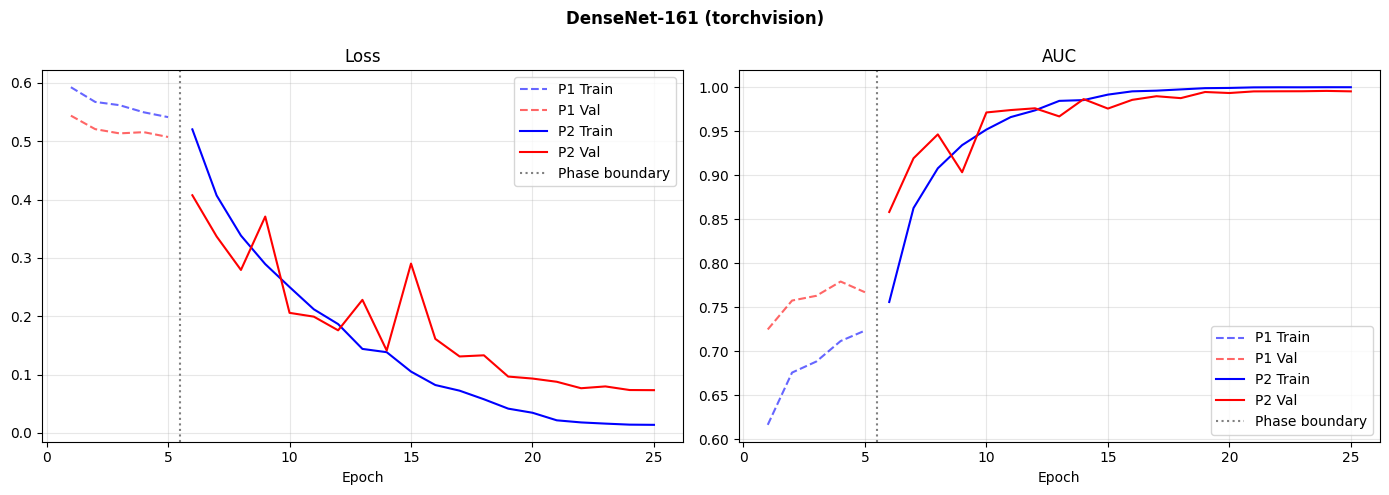

In [12]:
def plot_history(h1, h2):
    n1 = len(h1['train_loss'])
    n2 = len(h2['train_loss'])
    x1 = list(range(1, n1+1))
    x2 = list(range(n1+1, n1+n2+1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(MODEL_NAME, fontsize=12, fontweight='bold')

    for ax, key, title in [(axes[0],'loss','Loss'),(axes[1],'auc','AUC')]:
        ax.plot(x1, h1[f'train_{key}'], 'b--', alpha=0.6, label='P1 Train')
        ax.plot(x1, h1[f'val_{key}'],   'r--', alpha=0.6, label='P1 Val')
        ax.plot(x2, h2[f'train_{key}'], 'b-',             label='P2 Train')
        ax.plot(x2, h2[f'val_{key}'],   'r-',             label='P2 Val')
        ax.axvline(n1+0.5, color='gray', ls=':', label='Phase boundary')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()

plot_history(hist_p1, hist_p2)

## 13. Test Set Evaluation

In [13]:
model.eval()
_, test_auc, all_probs, all_labels = run_epoch(model, test_loader, training=False)
all_preds = all_probs.argmax(axis=1)

print(f'Test AUC : {test_auc:.4f}\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

Test AUC : 0.9970

              precision    recall  f1-score   support

          ET       0.96      0.97      0.97       358
          PD       0.99      0.98      0.99       849

    accuracy                           0.98      1207
   macro avg       0.97      0.98      0.98      1207
weighted avg       0.98      0.98      0.98      1207



## 14. Confusion Matrix & ROC Curve

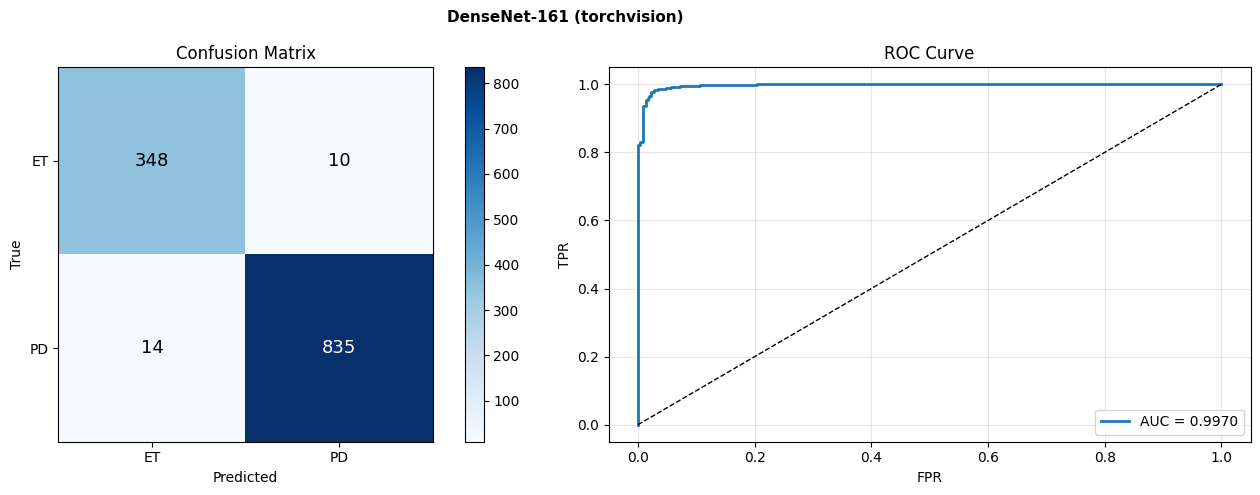

In [14]:
fig = plt.figure(figsize=(14, 5))
fig.suptitle(MODEL_NAME, fontsize=11, fontweight='bold')
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ── Confusion matrix ──────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
cm  = confusion_matrix(all_labels, all_preds)
im  = ax0.imshow(cm, cmap='Blues')
ax0.set_title('Confusion Matrix')
ax0.set_xlabel('Predicted'); ax0.set_ylabel('True')
ax0.set_xticks(range(NUM_CLASSES)); ax0.set_xticklabels(CLASS_NAMES)
ax0.set_yticks(range(NUM_CLASSES)); ax0.set_yticklabels(CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax0.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=13,
                 color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=ax0)

# ── ROC curve ─────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
if NUM_CLASSES == 2:
    fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
    ax1.plot(fpr, tpr, lw=2, label=f'AUC = {test_auc:.4f}')
else:
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
        ax1.plot(fpr, tpr, lw=1.5, label=f'{cls}  AUC={sk_auc(fpr,tpr):.3f}')
ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.set_title('ROC Curve')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(); ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'evaluation.png'), dpi=150)
plt.show()

## 15. Inference Speed Test

In [15]:
model.eval()
dummy = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    for _ in range(20): model(dummy)   # warmup

times = []
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        model(dummy)
        if DEVICE.type == 'cuda': torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
std_ms  = np.std(times)  * 1000
print(f'Single-image inference : {mean_ms:.2f} ± {std_ms:.2f} ms')
print(f'Sub-second requirement : {"✓ PASS" if mean_ms < 1000 else "✗ FAIL"}')

Single-image inference : 22.21 ± 0.74 ms
Sub-second requirement : ✓ PASS


## 16. Save Checkpoint

In [16]:
# Sanitize model name for filename
safe_name = MODEL_NAME.lower().replace(' ', '_').replace('(','').replace(')','').replace('+','_')
ckpt_name = f'{safe_name}.pth'
ckpt_path = os.path.join(OUTPUT_DIR, ckpt_name)

torch.save({
    'model_state_dict' : model.state_dict(),
    'model_name'       : MODEL_NAME,
    'family'           : FAMILY,
    'img_size'         : IMG_SIZE,
    'in_channels'      : 1,
    'num_classes'      : NUM_CLASSES,
    'class_names'      : CLASS_NAMES,
    'test_auc'         : test_auc,
    'best_val_auc'     : best_auc_p2,
    'best_epoch'       : best_ep,
    'phase1_epochs'    : PHASE1_EPOCHS,
    'phase2_epochs'    : len(hist_p2['train_loss']),
    'inference_ms'     : mean_ms,
}, ckpt_path)

print(f'Checkpoint : {ckpt_path}')
print(f'\nSummary')
print(f'  Model       : {MODEL_NAME}')
print(f'  Family      : {FAMILY}')
print(f'  Best Val AUC: {best_auc_p2:.4f}  (epoch {best_ep})')
print(f'  Test AUC    : {test_auc:.4f}')
print(f'  Inference   : {mean_ms:.2f} ms')

Checkpoint : /kaggle/working/outputs/densenet-161_torchvision.pth

Summary
  Model       : DenseNet-161 (torchvision)
  Family      : torchvision
  Best Val AUC: 0.9957  (epoch 19)
  Test AUC    : 0.9970
  Inference   : 22.21 ms


## 17. (Optional) Train All Models — Benchmark Run

Loops over every model in the registry, trains it, and saves a summary CSV.
Only run if you have enough GPU time (B5–B7 + V2-L are large).

In [17]:
RUN_ALL = False    # ← set to True to benchmark all models

if RUN_ALL:
    import csv
    summary_rows = []
    results_csv  = os.path.join(OUTPUT_DIR, 'all_models_benchmark.csv')

    for name, mcfg in MODEL_REGISTRY.items():
        print(f'\n{"═"*60}')
        print(f'  Training: {name}')
        print(f'{"═"*60}')

        if mcfg['family'] == 'monai' and not MONAI_AVAILABLE:
            print('  Skipped — MONAI not installed')
            continue

        # Rebuild loaders at the right image size
        _sz = mcfg['img_size']
        _fam = mcfg['family']

        if _fam == 'monai' and MONAI_AVAILABLE:
            _train_tf2 = Compose([
                LoadImaged(keys=['image']), EnsureChannelFirstd(keys=['image']),
                Lambdad(keys=['image'], func=lambda x: x[:1]),
                ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
                ResizeD(keys=['image'], spatial_size=(_sz, _sz)),
                RandFlipd(keys=['image'], prob=0.5, spatial_axis=0),
                RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
                RandRotated(keys=['image'], range_x=0.15, prob=0.5),
                ToTensord(keys=['image']),
            ])
            _val_tf2 = Compose([
                LoadImaged(keys=['image']), EnsureChannelFirstd(keys=['image']),
                Lambdad(keys=['image'], func=lambda x: x[:1]),
                ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
                ResizeD(keys=['image'], spatial_size=(_sz, _sz)),
                ToTensord(keys=['image']),
            ])
            _tr_ds = _MonaiWrapper(train_data, _train_tf2)
            _va_ds = _MonaiWrapper(val_data,   _val_tf2)
            _te_ds = _MonaiWrapper(test_data,  _val_tf2)
        else:
            _tf_tr = transforms.Compose([transforms.Resize((_sz,_sz)), transforms.RandomHorizontalFlip(), transforms.ToTensor()])
            _tf_va = transforms.Compose([transforms.Resize((_sz,_sz)), transforms.ToTensor()])
            _tr_ds = _TVDataset(train_data, _tf_tr)
            _va_ds = _TVDataset(val_data,   _tf_va)
            _te_ds = _TVDataset(test_data,  _tf_va)

        _tr_ld = DataLoader(_tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
        _va_ld = DataLoader(_va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        _te_ld = DataLoader(_te_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

        _model = mcfg['build'](NUM_CLASSES).to(DEVICE)
        freeze_backbone(_model, _fam)

        _opt1 = Adam(filter(lambda p: p.requires_grad, _model.parameters()), lr=PHASE1_LR)
        for _ in range(PHASE1_EPOCHS):
            run_epoch(_model, _tr_ld, _opt1, training=True)

        unfreeze_all(_model)
        _opt2  = Adam(_model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)
        _sched = CosineAnnealingLR(_opt2, T_max=PHASE2_EPOCHS, eta_min=1e-6)
        _best_auc, _best_w, _no_imp = 0.0, None, 0

        for ep in range(1, PHASE2_EPOCHS+1):
            run_epoch(_model, _tr_ld, _opt2, training=True)
            _, _va_auc, _, _ = run_epoch(_model, _va_ld, training=False)
            _sched.step()
            if _va_auc > _best_auc:
                _best_auc = _va_auc
                _best_w   = copy.deepcopy(_model.state_dict())
                _no_imp   = 0
            else:
                _no_imp += 1
                if _no_imp >= EARLY_STOP_PAT: break

        if _best_w: _model.load_state_dict(_best_w)

        _, _te_auc, _probs, _lbls = run_epoch(_model, _te_ld, training=False)

        # Speed
        _dummy = torch.randn(1, 1, _sz, _sz).to(DEVICE)
        with torch.no_grad():
            for _ in range(10): _model(_dummy)
        _ts = []
        with torch.no_grad():
            for _ in range(50):
                _t0 = time.perf_counter(); _model(_dummy)
                if DEVICE.type=='cuda': torch.cuda.synchronize()
                _ts.append(time.perf_counter()-_t0)
        _ms = np.mean(_ts)*1000

        # Save
        _safe = name.lower().replace(' ','_').replace('(','').replace(')','').replace('+','_')
        torch.save({
            'model_state_dict': _best_w,
            'model_name': name, 'family': _fam,
            'img_size': _sz, 'in_channels': 1,
            'num_classes': NUM_CLASSES, 'class_names': CLASS_NAMES,
            'test_auc': _te_auc, 'best_val_auc': _best_auc, 'inference_ms': _ms,
        }, os.path.join(OUTPUT_DIR, f'{_safe}.pth'))

        summary_rows.append({
            'model': name, 'family': _fam,
            'val_auc': round(_best_auc, 4),
            'test_auc': round(_te_auc, 4),
            'inference_ms': round(_ms, 2),
            'img_size': _sz,
        })
        print(f'  Val AUC={_best_auc:.4f}  Test AUC={_te_auc:.4f}  Latency={_ms:.1f}ms')
        del _model; torch.cuda.empty_cache()

    # Write CSV
    with open(results_csv, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['model','family','val_auc','test_auc','inference_ms','img_size'])
        w.writeheader(); w.writerows(summary_rows)

    print(f'\nBenchmark saved → {results_csv}')
    summary_rows.sort(key=lambda r: -r['test_auc'])
    print(f'{"Model":<45} {"Val AUC":>8} {"Test AUC":>9} {"ms":>7}')
    print('─'*75)
    for r in summary_rows:
        print(f"{r['model']:<45} {r['val_auc']:>8.4f} {r['test_auc']:>9.4f} {r['inference_ms']:>7.1f}")